In [11]:
from pathlib import Path
import shutil

# FOR EACH Dataset create an images/ labels/ folder with the global class indexes to work on them. Should only run once

GLOBAL_CLASS_DICT = {"bud":0, "buds":0, "Bud":0, "flower":1, "Flower":1, "green":2, "Green":2, "pink":3, "purple":3, "pink-purple":3, "blue":4}
# THose are the datasets I will verify my model and finetune on
uuids = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9", "33424749-501c-425e-bea5-3c74fb8539b4", "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c",
         "7dbfaa1b-19f1-479c-ab0a-b8081516de33", "0cc79c26-3350-4e0b-af74-3578c3970157", "b1d30ef2-0953-45bb-a65f-99770ed0dce3"]
for uuid in uuids:
  RAW_DATASET_ROOT = Path().cwd().parents[0] / "data" / "raw" / "finetuning" / uuid 
  PROCESSED_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "finetuning-global-labels" / uuid
  (PROCESSED_DATASET_ROOT / "images").mkdir(parents=True, exist_ok=True)
  (PROCESSED_DATASET_ROOT / "labels").mkdir(parents=True, exist_ok=True)


  # CREATE new image-label.txt pairs with global class indexes
  obj_names_path = RAW_DATASET_ROOT /"annotations/obj.names"
  local_cls_names = obj_names_path.open(encoding='utf-8').read().splitlines()
  for cls_name in local_cls_names:
    if cls_name not in GLOBAL_CLASS_DICT.keys():
      raise ValueError(f"class {cls_name} not in GLOBAL classes")

  labels_dir = RAW_DATASET_ROOT / "annotations/obj_train_data"

  local_class_idx_to_global_map = {i: GLOBAL_CLASS_DICT[cls_name] for i, cls_name in enumerate(local_cls_names)}
  print(f"Local class names: {local_cls_names} mapped with: {local_class_idx_to_global_map}")
  for label_file in labels_dir.iterdir():
    new_lines = []

    with label_file.open(encoding = 'utf-8') as f:
      for line in f:
        parts = line.strip().split()
        local_cls_idx = int(parts[0])
        global_cls_idx = local_class_idx_to_global_map[local_cls_idx]
        parts[0] = str(global_cls_idx)
        new_lines.append(" ".join(parts))

    out_label_path = PROCESSED_DATASET_ROOT / "labels" / label_file.name
    # print(out_label_path)
    '''
    out_label_path.write_text("\n".join(new_lines))
    '''
    if uuid == "f54bc9dd-bb2e-4b46-b332-a14a594245a9":
      img_name = label_file.with_suffix(".jpg").name
    else:
      img_name = label_file.with_suffix(".png").name
    src_img = RAW_DATASET_ROOT / "images" / img_name
    dst_img = PROCESSED_DATASET_ROOT / "images" / img_name
    '''
    if src_img.exists():
      shutil.copy(src_img ,dst_img)
    else:
      raise ValueError(f"{src_img} does not exist")
    '''

Local class names: ['blue', 'bud', 'flower', 'green', 'pink-purple'] mapped with: {0: 4, 1: 0, 2: 1, 3: 2, 4: 3}
Local class names: ['bud', 'flower', 'green', 'pink-purple', 'blue'] mapped with: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
Local class names: ['bud', 'flower', 'green', 'pink-purple', 'blue'] mapped with: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
Local class names: ['bud', 'flower', 'green', 'pink-purple', 'blue'] mapped with: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
Local class names: ['flower', 'bud', 'green', 'pink', 'blue'] mapped with: {0: 1, 1: 0, 2: 2, 3: 3, 4: 4}
Local class names: ['flower', 'bud', 'green', 'pink', 'purple', 'blue'] mapped with: {0: 1, 1: 0, 2: 2, 3: 3, 4: 3, 5: 4}


In [16]:
import os
# needed when use_determinist_algoriithms is used in CUDA > 10.2, before importing pytorch
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTHONHASHSEED"] = "0"
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent)) # to be able to import from src

import shutil
import random
from dataclasses import dataclass
# from collections import Counter, defaultdict
from itertools import islice
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import ConfusionMatrixDisplay
from src.utils.metrics import compute_classification_metrics_for_classifier_yolo_comparison
from src.utils.reproducibility import seed_everything
import mlflow
# import mlflow.pytorch

UUIDS = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9", "33424749-501c-425e-bea5-3c74fb8539b4", "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c",
         "7dbfaa1b-19f1-479c-ab0a-b8081516de33", "0cc79c26-3350-4e0b-af74-3578c3970157", "b1d30ef2-0953-45bb-a65f-99770ed0dce3"]

In [2]:
@dataclass
class BBox:
  cls: int # index
  xc: float # normalized
  yc: float
  w: float
  h: float

  def to_xyxy(self, img_h, img_w) -> tuple[int, int, int, int]:
    x1 = (self.xc - self.w/2) * img_w # x_min
    y1 = (self.yc - self.h/2) * img_h # y_min
    x2 = (self.xc + self.w/2) * img_w # x_max
    y2 = (self.yc + self.h/2) * img_h # y_max
    return x1, y1, x2, y2 # NOTE: removed int(round()) to not lose subpixel precision.. I am not sure it is correct..
    # return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))

def load_gt(label_file, img_h, img_w):
  '''
  gt bbox = (cls, [x1,y1,x2,y2])
  '''
  gt_boxes = []
  with label_file.open(encoding='utf-8') as f:
    for line in f:
      cls, xc, yc, w, h = map(float, line.split())
      box = BBox(int(cls),xc,yc,w,h)
      x1, y1, x2, y2 = box.to_xyxy(img_h, img_w)
      gt_boxes.append((int(cls), [x1, y1, x2, y2]))

  return gt_boxes

# ==========================================================================================================================
# LOAD classifier model
seed_everything(123456789)
DEVICE = "cuda:0"
tracking_uri = Path("../experiments/mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{tracking_uri}")
run_id = "7f572b99e4224dbe98221ffff3557390" # swinv2tiny
# run_id = "2ec89cf7ed2e4bac921a69f5902285ab" # swinv2tiny-aug-cosinewr7-defaultsampl
# run_id = "7626a94ac30f40bb8b88d3c7e69b9eae" # hpo.convnexttiny.weighted.aug.correct-trial-16 in merged-pinkblue runs
client = mlflow.tracking.MlflowClient()
run = client.get_run(run_id)
# print(run.data.params['data']) # this is string -> i have to use regular expr to parse mean/std -> ugly!
model = mlflow.pytorch.load_model(f"runs:/{run_id}/best_model")
model.to(DEVICE)
model.eval()

mean = [0.4291, 0.5388, 0.3654]
std = [0.1871, 0.2131, 0.1977]
inference_transform = v2.Compose([
  v2.ToImage(),
  v2.Resize((64,64), interpolation=v2.InterpolationMode.BICUBIC),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=mean, std=std) # depends on which model i choose , what dataset it was trained
])
# ==========================================================================================================================

datasets:   0%|          | 0/6 [00:09<?, ?it/s]

UUID = f54bc9dd-bb2e-4b46-b332-a14a594245a9
acc 72.56% | balanced_acc: 50.08% | f1_macro: 41.46% | f1_weighted: 82.41% | precision_macro: 46.66% | precision_weighted: 95.77% | recall_macro: 50.08% | recall_weighted: 72.56%


,precision,recall,f1-score,support
bud,0.000,0.000,0.000,3
flower,0.974,65.812,1.920,117
green,98.308,73.941,84.401,30880
pink-purple,66.498,50.229,57.230,1312
blue,67.511,60.394,63.755,1015
accuracy,72.560,72.560,72.560,0
macro avg,46.658,50.075,41.461,33327
weighted avg,95.767,72.560,82.405,33327


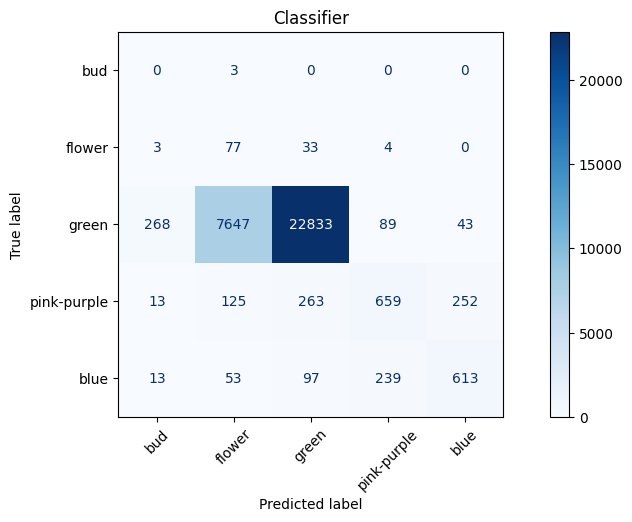

datasets:  17%|█▋        | 1/6 [00:39<00:47,  9.47s/it]

UUID = 33424749-501c-425e-bea5-3c74fb8539b4
acc 83.87% | balanced_acc: 49.05% | f1_macro: 42.14% | f1_weighted: 88.65% | precision_macro: 50.04% | precision_weighted: 94.67% | recall_macro: 49.05% | recall_weighted: 83.87%


,precision,recall,f1-score,support
bud,0.000,0.000,0.000,1
flower,2.245,65.714,4.342,280
green,96.842,87.395,91.876,70606
pink-purple,60.949,37.689,46.576,3375
blue,90.145,54.438,67.883,2974
accuracy,83.874,83.874,83.874,0
macro avg,50.036,49.047,42.135,77236
weighted avg,94.672,83.874,88.654,77236


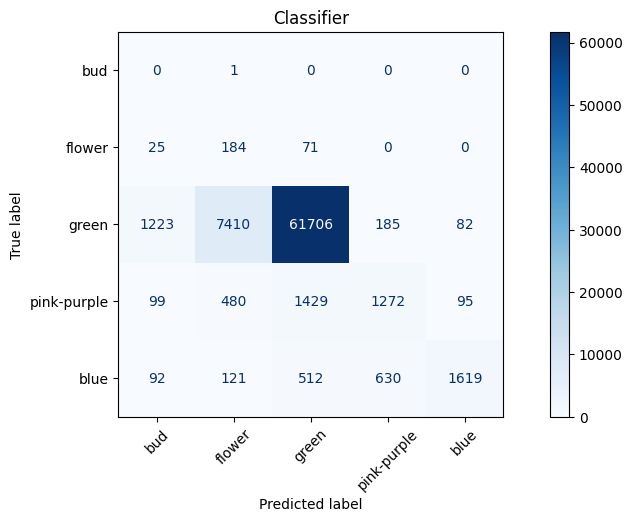

100%|██████████| 300/300 [00:16<00:00, 18.18it/s]3s/it]
/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
datasets:  33%|███▎      | 2/6 [00:56<01:27, 21.83s/it]

UUID = d83c7c85-54d9-4b6e-ab2e-3fdec827c22c
acc 68.82% | balanced_acc: 49.12% | f1_macro: 42.20% | f1_weighted: 70.23% | precision_macro: 48.94% | precision_weighted: 72.86% | recall_macro: 39.29% | recall_weighted: 68.82%


,precision,recall,f1-score,support
bud,0.000,0.000,0.000,0
flower,61.333,62.842,62.078,1098
green,80.579,79.469,80.020,2976
pink-purple,31.667,8.261,13.103,230
blue,71.111,45.902,55.791,488
accuracy,68.823,68.823,68.823,0
macro avg,48.938,39.295,42.199,4792
weighted avg,72.858,68.823,70.230,4792


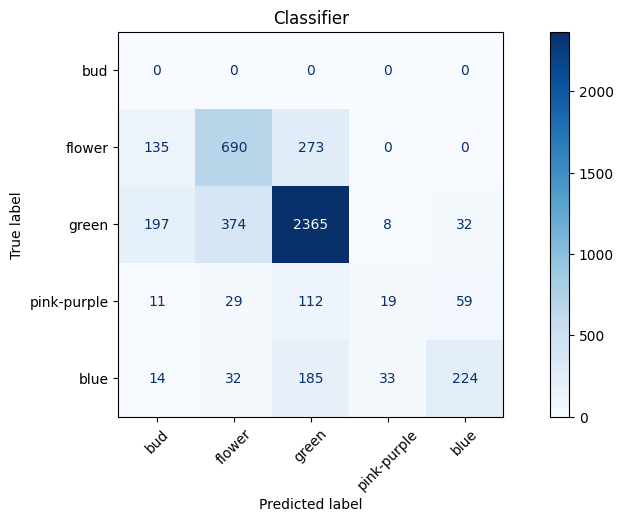

100%|██████████| 300/300 [00:22<00:00, 13.14it/s]3s/it]
/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
datasets:  50%|█████     | 3/6 [01:19<00:58, 19.43s/it]

UUID = 7dbfaa1b-19f1-479c-ab0a-b8081516de33
acc 80.40% | balanced_acc: 64.47% | f1_macro: 36.08% | f1_weighted: 80.09% | precision_macro: 38.99% | precision_weighted: 83.41% | recall_macro: 51.57% | recall_weighted: 80.40%


,precision,recall,f1-score,support
bud,0.000,0.000,0.000,0
flower,86.846,50.410,63.792,13307
green,82.019,94.366,87.761,28984
pink-purple,18.966,13.095,15.493,84
blue,7.143,100.000,13.333,1
accuracy,80.402,80.402,80.402,0
macro avg,38.995,51.574,36.076,42376
weighted avg,83.408,80.402,80.089,42376


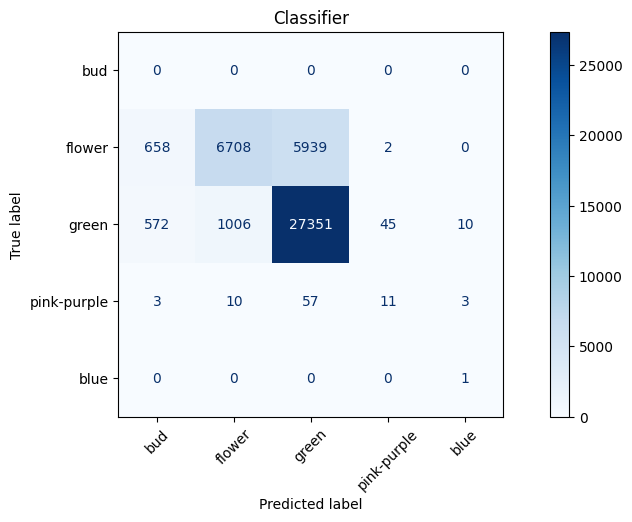

datasets:  67%|██████▋   | 4/6 [01:42<00:41, 20.85s/it]

UUID = 0cc79c26-3350-4e0b-af74-3578c3970157
acc 48.20% | balanced_acc: 50.47% | f1_macro: 39.73% | f1_weighted: 49.52% | precision_macro: 51.89% | precision_weighted: 67.75% | recall_macro: 50.47% | recall_weighted: 48.20%


,precision,recall,f1-score,support
bud,37.934,68.275,48.771,5346
flower,9.667,69.652,16.978,1005
green,50.194,63.490,56.064,16105
pink-purple,64.964,15.159,24.581,4697
blue,96.683,35.799,52.251,17749
accuracy,48.196,48.196,48.196,0
macro avg,51.888,50.475,39.729,44902
weighted avg,67.748,48.196,49.521,44902


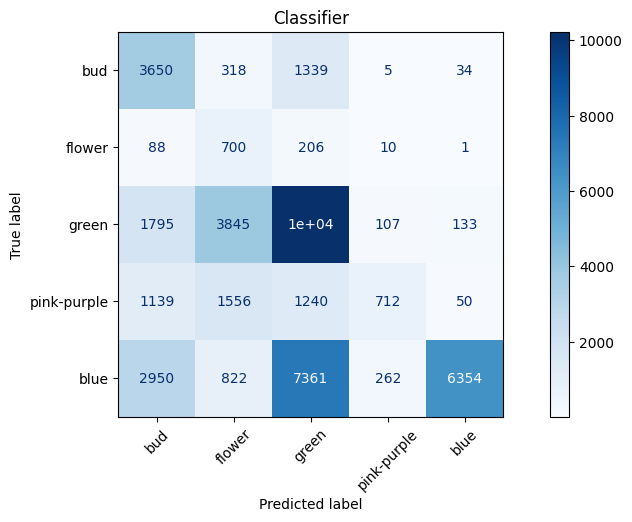

datasets:  83%|████████▎ | 5/6 [01:59<00:21, 21.46s/it]

UUID = b1d30ef2-0953-45bb-a65f-99770ed0dce3
acc 70.59% | balanced_acc: 50.00% | f1_macro: 40.21% | f1_weighted: 72.42% | precision_macro: 44.33% | precision_weighted: 76.40% | recall_macro: 50.00% | recall_weighted: 70.59%


,precision,recall,f1-score,support
bud,0.595,3.125,1.000,32
flower,3.882,69.048,7.351,42
green,81.573,86.628,84.025,5003
pink-purple,57.390,33.256,42.110,1296
blue,78.188,57.931,66.552,2339
accuracy,70.592,70.592,70.592,0
macro avg,44.326,49.998,40.208,8712
weighted avg,76.395,70.592,72.424,8712


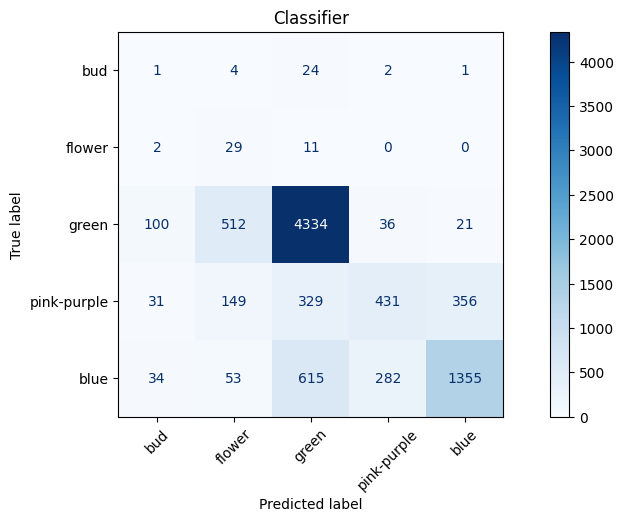

datasets: 100%|██████████| 6/6 [01:59<00:00, 19.97s/it]


In [3]:
LABEL_IDS = [0, 1, 2, 3, 4]
CLASS_NAMES = ["bud", "flower", "green", "pink-purple", "blue"]
CLASS_MAPPING = {str(id):CLASS_NAMES[id] for id in LABEL_IDS} # for use in classification report df
uuids = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9", "33424749-501c-425e-bea5-3c74fb8539b4", "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c",
         "7dbfaa1b-19f1-479c-ab0a-b8081516de33", "0cc79c26-3350-4e0b-af74-3578c3970157", "b1d30ef2-0953-45bb-a65f-99770ed0dce3"]
# uuid = "f54bc9dd-bb2e-4b46-b332-a14a594245a9"
for uuid in tqdm(uuids, desc="datasets", position=0):
  TEST_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "finetuning-global-labels" / uuid
  IMAGES_DIR = TEST_DATASET_ROOT / "images"
  LABELS_DIR = TEST_DATASET_ROOT / "labels"

  y_true = []
  y_pred = []
  # for i, label_file in islice(enumerate(LABELS_DIR.iterdir()), 2):
  for label_file in tqdm(sorted(LABELS_DIR.iterdir())):
    if uuid == "f54bc9dd-bb2e-4b46-b332-a14a594245a9":
      img_file = IMAGES_DIR / label_file.with_suffix('.jpg').name
    else:
      img_file = IMAGES_DIR / label_file.with_suffix('.png').name
    img_rgb = Image.open(img_file).convert("RGB")
    img_h, img_w = img_rgb.height, img_rgb.width
    assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"

    gt_boxes = load_gt(label_file, img_h, img_w) # a list of (label, [x1,y1,x2,y2])
    if len(gt_boxes) == 0:
      continue
    y_true_per_image = []
    y_pred_per_image = []
    crops = [] # to create a batch with all the boxes from this label file
    for gt in gt_boxes:
      gt_cls, gt_box = gt
      crop = img_rgb.crop(gt_box)
      # crop_transformed = inference_transform(crop).unsqueeze(0).to(DEVICE)
      crops.append(inference_transform(crop))
      y_true_per_image.append(gt_cls)
    
    crops_batch = torch.stack(crops).to(DEVICE)
    # print(crops_batch.shape, len(y_true_per_image))
    with torch.inference_mode():
      logits = model(crops_batch).cpu()
      classifier_probs = nn.Softmax(dim=1)(logits)#.cpu() # (1, n_classes)
    classifier_pred = logits.argmax(dim=1).cpu().numpy() # (batch, )
    # classifier_conf = classifier_probs[:, classifier_pred].cpu().numpy()
    # print(classifier_pred.shape)
    # y_pred_per_image.append(classifier_pred)
    y_true.extend(y_true_per_image)
    y_pred.extend(classifier_pred.tolist())

    assert len(y_true_per_image) == len(classifier_pred)

  classifier_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_pred, y_true, LABEL_IDS)
  classifier_classification_report = classifier_metrics['classification_report']

  tqdm.write(f"UUID = {uuid}")
  tqdm.write(f"acc {classifier_metrics['acc']:.2f}% | " f"balanced_acc: {classifier_metrics['balanced_acc']:.2f}% | "
        f"f1_macro: {classifier_metrics['f1_macro']:.2f}% | " f"f1_weighted: {classifier_metrics['f1_weighted']:.2f}% | "
        f"precision_macro: {classifier_metrics['precision_macro']:.2f}% | " f"precision_weighted: {classifier_metrics['precision_weighted']:.2f}% | "
        f"recall_macro: {classifier_metrics['recall_macro']:.2f}% | " f"recall_weighted: {classifier_metrics['recall_weighted']:.2f}%"
  )
  METRIC_COLUMNS = ["precision", "recall", "f1-score"]
  classifier_df = pd.DataFrame(classifier_classification_report).transpose()
  classifier_df = classifier_df.rename(index=CLASS_MAPPING)
  classifier_df[METRIC_COLUMNS] = classifier_df[METRIC_COLUMNS] * 100
  classifier_df["support"] = classifier_df["support"].astype(int)
  display(classifier_df.style.format(precision=3).set_caption("Classifier"))

  classifier_conf_matrix = classifier_metrics['confusion_matrix']
  fig, ax = plt.subplots(1, 1, figsize=(12,5))
  disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix, display_labels=CLASS_NAMES)
  # disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix)
  disp_conf_matrix.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
  ax.set_title("Classifier");
  plt.show()

In [ ]:
for param in model.parameters():
  param.requires_grad = False
for param in model.head.parameters():
  param.requires_grad = True

def freeze_backbone(model):
  for name, param in model.named_parameters():
    if not name.startswith("head"):
      param.requires_grad = False
    else:
      param.requires_grad = True

freeze_backbone(model)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable} out of total: {total}")

# classifier.train()

optimizer = torch.optim.AdamW(model.head.parameters(), lr=1e-4)

Trainable params: 3845 out of total: 27581999


In [10]:
rng = random.Random(42)

N_IMAGES_TO_USE_IN_FINETUNE = [50, 100, 150]
# uuid = UUIDS[0]
for uuid in UUIDS:
  GLOBAL_LABELS_SRC_DATASET = Path().cwd().parents[0] / "data" / "processed" / "finetuning-global-labels" / uuid
  GLOBAL_LABELS_IMAGES_DIR = GLOBAL_LABELS_SRC_DATASET / "images"
  GLOBAL_LABELS_LABELS_DIR = GLOBAL_LABELS_SRC_DATASET / "labels"

  for n_images in N_IMAGES_TO_USE_IN_FINETUNE:
    # dataset root for each finetune sample size
    BEFORE_SPLIT_ROOT = Path().cwd().parents[0] / "data" / "processed" / f"finetuning-before-split-{n_images}"
    BEFORE_SPLIT_DATASET = BEFORE_SPLIT_ROOT / uuid
    if BEFORE_SPLIT_ROOT.exists():
      shutil.rmtree(BEFORE_SPLIT_ROOT)
    for cls_id in range(5):
      (BEFORE_SPLIT_DATASET / str(cls_id)).mkdir(parents=True, exist_ok=True)

    label_files_names = ([f for f in GLOBAL_LABELS_LABELS_DIR.iterdir() if f.stat().st_size>0]) # ignore empty label files
    label_files_sample = rng.sample(label_files_names, min(len(label_files_names), n_images)) # if labels < 150 for one uuid use them all
    # print(label_files_sample[:3])
    # print(f"sample {n_images}")
    # print(f"Total label files: {len(label_files_names)}")
    # print(f"sampled = {len(label_files_sample)}")
    # create dataset from the boxes for the selected amount of images
    for label_file in label_files_sample:
      suffix = ".jpg" if uuid == "f54bc9dd-bb2e-4b46-b332-a14a594245a9" else ".png"
      img_path = GLOBAL_LABELS_IMAGES_DIR / label_file.with_suffix(suffix).name
      img_rgb = Image.open(img_path).convert("RGB")
      img_h, img_w = img_rgb.height, img_rgb.width
      assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"

      gt_boxes = load_gt(label_file, img_h, img_w)
      assert gt_boxes, f"parsed empty label file {label_file}. Shouldn't happen"

      # copy bboxes to intermidiate before-split dataset for each cls
      for i, (gt_cls, gt_box) in enumerate(gt_boxes):
        crop = img_rgb.crop(gt_box)
        dst_box_path = BEFORE_SPLIT_DATASET / f"{str(gt_cls) + '/' + img_path.stem}_{i}.png" # write all crops as png ,even from .jpg images
        # print(dst_box_path)
        crop.save(dst_box_path)


    SPLITTED_ROOT = Path().cwd().parents[0] / "data" / "processed" / f"finetuning-splitted-{n_images}"
    SPLITTED_DATASET = SPLITTED_ROOT / uuid
    if SPLITTED_DATASET.exists():
      shutil.rmtree(SPLITTED_DATASET)
    (train_folder := SPLITTED_DATASET / "train").mkdir(parents=True, exist_ok=True)
    (dev_folder := SPLITTED_DATASET / "dev").mkdir(parents=True, exist_ok=True)
    train_ratio = 0.9 # 90% train, 10% dev

    for cls_dir in BEFORE_SPLIT_DATASET.iterdir():
      cls_name = cls_dir.name
      (train_class_folder := train_folder / cls_name).mkdir(parents=True, exist_ok=True)
      (dev_class_folder := dev_folder / cls_name).mkdir(parents=True, exist_ok=True)

      images = list(cls_dir.glob(f"*.png"))
      rng.shuffle(images)

      split_idx = int(len(images) * train_ratio)
      train_images = images[:split_idx]
      dev_images = images[split_idx:]

      # print("train, test len =", len(train_images), len(dev_images))
      # copy files
      for img_path in train_images:
        shutil.copy(img_path, train_class_folder / img_path.name)
      for img_path in dev_images:
        shutil.copy(img_path, dev_class_folder / img_path.name)

    # Delete intermediate before-split dataset
    if BEFORE_SPLIT_ROOT.exists():
      shutil.rmtree(BEFORE_SPLIT_ROOT)

In [21]:
# finetune
DEVICE = "cuda:0"
EPOCHS = 100
BATCH_SIZE = 128

mean = [0.4291, 0.5388, 0.3654]
std = [0.1871, 0.2131, 0.1977]
train_transforms = v2.Compose([
  v2.ToImage(),
  v2.Resize((64,64), interpolation=v2.InterpolationMode.BICUBIC),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=mean, std=std)
])

dev_transforms = v2.Compose([
  v2.ToImage(),
  v2.Resize((64,64), interpolation=v2.InterpolationMode.BICUBIC),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=mean, std=std)
])

def get_loaders(uuid_path):
  train_ds = ImageFolder(uuid_path / "train", transform=train_transforms, allow_empty=True)
  dev_ds   = ImageFolder(uuid_path / "dev", transform=dev_transforms, allow_empty=True)
  train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
  dev_loader   = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False)

  return train_loader, dev_loader

ROOT = Path().cwd().parents[0] / "data" / "processed" / "finetuning-splitted-50"

for uuid_dir in islice(ROOT.iterdir(), 1):
  print(uuid_dir)
  train_loader, dev_loader = get_loaders(uuid_dir)
  print(len(train_loader), len(dev_loader))

/home/kpetrakis/ml-sandbox/data/processed/finetuning-splitted-50/33424749-501c-425e-bea5-3c74fb8539b4
98 11


#### Inference on the boxes one by one

In [ ]:
# # uuids = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9", "33424749-501c-425e-bea5-3c74fb8539b4", "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c",
#         #  "7dbfaa1b-19f1-479c-ab0a-b8081516de33", "0cc79c26-3350-4e0b-af74-3578c3970157", "b1d30ef2-0953-45bb-a65f-99770ed0dce3"]
# uuid = "f54bc9dd-bb2e-4b46-b332-a14a594245a9"
# # uuids = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9"]
# # for uuid in tqdm(uuids, desc="datasets", position=0):
# TEST_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "finetuning-global-labels" / uuid
# IMAGES_DIR = TEST_DATASET_ROOT / "images"
# LABELS_DIR = TEST_DATASET_ROOT / "labels"
# LABEL_IDS = [0, 1, 2, 3, 4]
# CLASS_NAMES = ["bud", "flower", "green", "pink-purple", "blue"]
# CLASS_MAPPING = {str(id):CLASS_NAMES[id] for id in LABEL_IDS} # for use in classification report df

# y_true = []
# y_pred = []
# # for i, label_file in islice(enumerate(LABELS_DIR.iterdir()), 5):
# for label_file in tqdm(LABELS_DIR.iterdir()):
#   if uuid == "f54bc9dd-bb2e-4b46-b332-a14a594245a9":
#     img_file = IMAGES_DIR / label_file.with_suffix('.jpg').name
#   else:
#     img_file = IMAGES_DIR / label_file.with_suffix('.png').name
#   img_rgb = Image.open(img_file).convert("RGB")
#   img_h, img_w = img_rgb.height, img_rgb.width
#   assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"

#   gt_boxes = load_gt(label_file, img_h, img_w) # a list of (label, [x1,y1,x2,y2])
#   y_true_per_image = []
#   y_pred_per_image = []
#   for gt in gt_boxes:
#     gt_cls, gt_box = gt
#     crop = img_rgb.crop(gt_box)
#     crop_transformed = inference_transform(crop).unsqueeze(0).to(DEVICE)
#     with torch.inference_mode():
#       logits = classifier(crop_transformed).cpu()
#       classifier_probs = nn.Softmax(dim=1)(logits).cpu() # (1, n_classes)
#     classifier_pred = logits.argmax(dim=1).cpu().item()
#     classifier_conf = classifier_probs[:, classifier_pred].cpu().item()
#     y_true_per_image.append(gt_cls)
#     y_pred_per_image.append(classifier_pred)

#   y_true.extend(y_true_per_image)
#   y_pred.extend(y_pred_per_image)

# classifier_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_pred, y_true, LABEL_IDS)
# classifier_classification_report = classifier_metrics['classification_report']

# tqdm.write(f"UUID = {uuid}")
# tqdm.write(f"acc {classifier_metrics['acc']:.2f}% | " f"balanced_acc: {classifier_metrics['balanced_acc']:.2f}% | "
#       f"f1_macro: {classifier_metrics['f1_macro']:.2f}% | " f"f1_weighted: {classifier_metrics['f1_weighted']:.2f}% | "
#       f"precision_macro: {classifier_metrics['precision_macro']:.2f}% | " f"precision_weighted: {classifier_metrics['precision_weighted']:.2f}% | "
#       f"recall_macro: {classifier_metrics['recall_macro']:.2f}% | " f"recall_weighted: {classifier_metrics['recall_weighted']:.2f}%"
# )
# METRIC_COLUMNS = ["precision", "recall", "f1-score"]
# classifier_df = pd.DataFrame(classifier_classification_report).transpose()
# classifier_df = classifier_df.rename(index=CLASS_MAPPING)
# classifier_df[METRIC_COLUMNS] = classifier_df[METRIC_COLUMNS] * 100
# classifier_df["support"] = classifier_df["support"].astype(int)
# display(classifier_df.style.format(precision=3).set_caption("Classifier"))

# classifier_conf_matrix = classifier_metrics['confusion_matrix']
# fig, ax = plt.subplots(1, 1, figsize=(12,5))
# disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix, display_labels=CLASS_NAMES)
# # disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix)
# disp_conf_matrix.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
# ax.set_title("Classifier");
# plt.show()